# Final model, how many to flag, and the final exam

1. Train the final model with the best settings from the grid search
2. Decide **how many purchases to flag**, looking at month 4 (valid)
3. See it in a chart
4. Turn "flag the top X%" into a **score threshold**
5. Compare with **simple rules** (what a bank would do without machine learning)
6. **Final exam** on month 5 (test), opened here for the first and only time
7. Which features the model uses most
8. Save the model

A reminder of the idea used everywhere below:

> The model gives every purchase a **score** from 0 to 1 (how suspicious it is).
> We sort the purchases from the highest score to the lowest (a **ranking**) and **flag** the top ones.
> Example with 5 purchases: scores 0.91, 0.40, 0.08, 0.03, 0.01 → if we flag 1, we flag the 0.91 one.

## 1. Train the final model

Same model as in the comparison (HistGradientBoosting), with the settings found by the grid search
(`best_params.json`). It learns on months 0–3; then it gives a score to every purchase of month 4.

Invented example of what we get at the end of this block (column `score`):

| purchase | amount | foreign card | score | was fraud |
|---|---|---|---|---|
| A | 480 $ | yes | 0.91 | yes |
| B | 35 $ | no | 0.02 | no |
| C | 120 $ | yes | 0.55 | no |

In [2]:
import json
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import average_precision_score, roc_auc_score

BLUE, PINK, GREY = "#A7C7E7", "#F4A7B9", "#6B6B6B"      # pastel colours for the charts
IMAGES = Path("../docs/images")
IMAGES.mkdir(parents=True, exist_ok=True)

df = pd.read_parquet("../data/processed/features.parquet")
info = json.load(open("features.json"))
FEATURES, CATEGORIES = info["features"], info["categories"]
for c in CATEGORIES:
    df[c] = df[c].astype("category")

train = df[df["split"] == "train"]
valid = df[df["split"] == "valid"].copy()

best_params = json.load(open("best_params.json"))
model = HistGradientBoostingClassifier(
    max_iter=1000, categorical_features="from_dtype",
    early_stopping=True, validation_fraction=0.1, n_iter_no_change=50,
    random_state=0, **best_params,
)
model.fit(train[FEATURES], train["isFraud"])
valid["score"] = model.predict_proba(valid[FEATURES])[:, 1]

print("trees used:", model.n_iter_)
print("PR-AUC on month 4:", round(average_precision_score(valid["isFraud"], valid["score"]), 3))
valid[["TransactionAmt", "foreign_card", "score", "isFraud"]].head()

trees used: 1000
PR-AUC on month 4: 0.597


,TransactionAmt,foreign_card,score,isFraud
410601,82.00,0,0.002648,0
410602,108.95,0,0.001981,0
410603,108.50,0,0.001774,0
410604,117.00,0,0.000943,0
410605,554.00,0,0.005930,0


## 2. How many purchases to flag?

We try to flag 0.5%, 1%, 2%, 3%, 5% and 10% of the purchases of month 4 (always the top of the ranking),
and for each we count:

- **frauds caught**: how many frauds are among the flagged (and as % of all the frauds of the month)
- **honest flagged**: how many honest customers we flagged by mistake
- **precision**: of the flagged, the % that are frauds
- **fraud $ caught**: the % of fraud dollars we catch

Invented example with 1,000 purchases and 35 frauds:

| flagged | frauds caught | honest flagged | precision |
|---|---|---|---|
| 10 (1%) | 9 of 35 (26%) | 1 | 90% |
| 50 (5%) | 25 of 35 (71%) | 25 | 50% |

Flagging more catches more frauds, but also more honest customers: this table shows the price of each step.

In [3]:
total_frauds = valid["isFraud"].sum()
total_fraud_dollars = valid.loc[valid["isFraud"] == 1, "TransactionAmt"].sum()
ranked = valid.sort_values("score", ascending=False)

def flag_top(share):
    """What happens if we flag the top `share` of the purchases."""
    flagged = ranked.head(int(len(ranked) * share))
    frauds = int(flagged["isFraud"].sum())
    return {
        "flagged %": share * 100,
        "flagged purchases": len(flagged),
        "frauds caught": frauds,
        "frauds caught %": round(frauds / total_frauds * 100, 1),
        "honest flagged": len(flagged) - frauds,
        "precision %": round(frauds / len(flagged) * 100, 1),
        "fraud $ caught %": round(flagged.loc[flagged["isFraud"] == 1, "TransactionAmt"].sum()
                                  / total_fraud_dollars * 100, 1),
        "score threshold": round(flagged["score"].min(), 3),
    }

table = pd.DataFrame([flag_top(s) for s in [0.005, 0.01, 0.02, 0.03, 0.05, 0.10]])
table

,flagged %,flagged purchases,frauds caught,frauds caught %,honest flagged,precision %,fraud $ caught %,score threshold
0,0.5,426,413,13.9,13,96.9,6.5,0.970
1,1.0,853,764,25.8,89,89.6,19.3,0.753
2,2.0,1706,1308,44.2,398,76.7,40.2,0.250
3,3.0,2559,1583,53.4,976,61.9,51.3,0.108
4,5.0,4265,1868,63.1,2397,43.8,63.2,0.050
5,10.0,8530,2225,75.1,6305,26.1,77.3,0.020


## 3. The same thing in a chart

For every share of flagged purchases from 0% to 15%:
- **pink**: % of frauds caught (goes up fast at the beginning, then slower)
- **blue**: honest customers flagged (goes up slowly at the beginning, then faster)

The good point is **where the pink line starts to flatten**: after it, every extra flag catches few new
frauds and bothers many honest customers.

Invented example: going from 2% to 3% flagged catches 150 more frauds and bothers 700 more honest customers;
going from 10% to 11% catches 20 more frauds and bothers 830 more honest customers → not worth it.

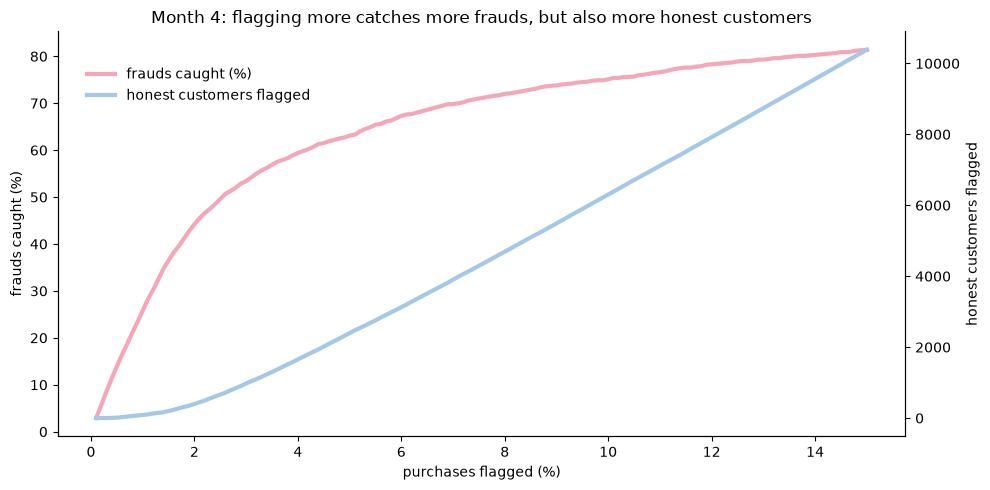

In [4]:
shares = np.linspace(0.001, 0.15, 150)
curve = pd.DataFrame([flag_top(s) for s in shares])

fig, left = plt.subplots(figsize=(10, 5))
left.plot(curve["flagged %"], curve["frauds caught %"], color=PINK, linewidth=3, label="frauds caught (%)")
left.set_xlabel("purchases flagged (%)")
left.set_ylabel("frauds caught (%)")
right = left.twinx()
right.plot(curve["flagged %"], curve["honest flagged"], color=BLUE, linewidth=3, label="honest customers flagged")
right.set_ylabel("honest customers flagged")
for ax in (left, right):
    ax.spines[["top"]].set_visible(False)
fig.legend(loc="upper left", bbox_to_anchor=(0.08, 0.88), frameon=False)
left.set_title("Month 4: flagging more catches more frauds, but also more honest customers")
plt.tight_layout()
plt.savefig(IMAGES / "flag_tradeoff.png", dpi=120)
plt.show()

## 4. From "top X%" to a score threshold

"Flag the top 2%" works on a month we already have. In real life purchases arrive one by one, and we
must decide immediately. So we turn the choice into a **score threshold**: *flag every purchase with a
score above T*.

T = the score of the last purchase inside the chosen top X% (column `score threshold` of the table).

Invented example: in the top 2% the lowest score is 0.38 → from now on, every purchase with score ≥ 0.38
is flagged.

**Change `FLAG_SHARE` if, looking at the table and the chart, you prefer another point.**

In [5]:
FLAG_SHARE = 0.02                                   # chosen looking at the table and the chart
THRESHOLD = flag_top(FLAG_SHARE)["score threshold"]
print(f"flag every purchase with score >= {THRESHOLD}")
flag_top(FLAG_SHARE)

flag every purchase with score >= 0.25


{'flagged %': 2.0,
 'flagged purchases': 1706,
 'frauds caught': 1308,
 'frauds caught %': np.float64(44.2),
 'honest flagged': 398,
 'precision %': 76.7,
 'fraud $ caught %': np.float64(40.2),
 'score threshold': np.float64(0.25)}

## 5. Compared with simple rules

A bank without machine learning would use rules written by hand, taken from the EDA. We test three:

- **rule A**: foreign card **and** at night (hours 5–10)
- **rule B**: product type C **and** no billing address
- **rule C**: amount with odd cents (currency conversion) **and** foreign card

For each rule: how many purchases it flags, and how many frauds. Then we give the model **the same number
of flags** and see how many frauds it catches. Same effort, different result.

Invented example: rule A flags 900 purchases and catches 200 frauds; the model, with 900 flags, catches 700.

In [6]:
night = valid["hour"].between(5, 10)
rules = {
    "rule A: foreign card and night": (valid["foreign_card"] == 1) & night,
    "rule B: product C and no address": (valid["ProductCD"] == "C") & (valid["addr1_missing"] == 1),
    "rule C: odd cents and foreign card": (valid["amt_odd_cents"] == 1) & (valid["foreign_card"] == 1),
}
rows = []
for name, flagged in rules.items():
    n = int(flagged.sum())
    rule_frauds = int(valid.loc[flagged, "isFraud"].sum())
    model_frauds = int(ranked.head(n)["isFraud"].sum())       # the model with the same number of flags
    rows.append({"rule": name, "flagged": n,
                 "frauds caught by the rule": rule_frauds,
                 "frauds caught by the model (same flags)": model_frauds})
pd.DataFrame(rows)

,rule,flagged,frauds caught by the rule,frauds caught by the model (same flags)
0,rule A: foreign card and night,616,185,569
1,rule B: product C and no address,8562,1102,2228
2,rule C: odd cents and foreign card,7679,962,2186


## 6. Final exam: month 5 (test)

Until now month 5 was closed. Now we use it **once**, with everything already decided (model, settings,
threshold). This is the honest grade: data the model and we have never looked at.

We apply the threshold T and count the four boxes (the **confusion matrix**):

| | was fraud | was honest |
|---|---|---|
| **flagged** | frauds caught ✔ | honest flagged by mistake ✘ |
| **not flagged** | frauds missed ✘ | honest left alone ✔ |

In [7]:
test = df[df["split"] == "test"].copy()
test["score"] = model.predict_proba(test[FEATURES])[:, 1]
test["flagged"] = (test["score"] >= THRESHOLD).astype(int)

y, f = test["isFraud"], test["flagged"]
caught, honest_flagged = int(((f == 1) & (y == 1)).sum()), int(((f == 1) & (y == 0)).sum())
missed, honest_ok = int(((f == 0) & (y == 1)).sum()), int(((f == 0) & (y == 0)).sum())
fraud_dollars = test.loc[y == 1, "TransactionAmt"].sum()
caught_dollars = test.loc[(y == 1) & (f == 1), "TransactionAmt"].sum()

print(pd.DataFrame({"was fraud": [caught, missed], "was honest": [honest_flagged, honest_ok]},
                   index=["flagged", "not flagged"]), "\n")
print(f"PR-AUC {average_precision_score(y, test['score']):.3f} | ROC-AUC {roc_auc_score(y, test['score']):.3f}")
print(f"flagged {f.mean() * 100:.1f}% of the purchases")
print(f"frauds caught: {caught} of {caught + missed} ({caught / (caught + missed) * 100:.1f}%)")
print(f"precision: {caught / max(caught + honest_flagged, 1) * 100:.1f}% of the flagged are frauds")
print(f"fraud dollars caught: ${caught_dollars:,.0f} of ${fraud_dollars:,.0f} ({caught_dollars / fraud_dollars * 100:.1f}%)")

             was fraud  was honest
flagged           1318         598
not flagged       1964       90756 

PR-AUC 0.513 | ROC-AUC 0.899
flagged 2.0% of the purchases
frauds caught: 1318 of 3282 (40.2%)
precision: 68.8% of the flagged are frauds
fraud dollars caught: $140,337 of $495,244 (28.3%)


## 7. Which features the model uses most

**Permutation importance**: take one column, **shuffle** its values between purchases (so it becomes
nonsense), and see how much the model gets worse. If it gets much worse, the model was using that column a lot.

Invented example: shuffling `foreign_card` drops the PR-AUC from 0.60 to 0.52 (−0.08, important);
shuffling `weekday` drops it from 0.60 to 0.599 (−0.001, almost unused).

Done on 20,000 purchases of month 4, to be faster.

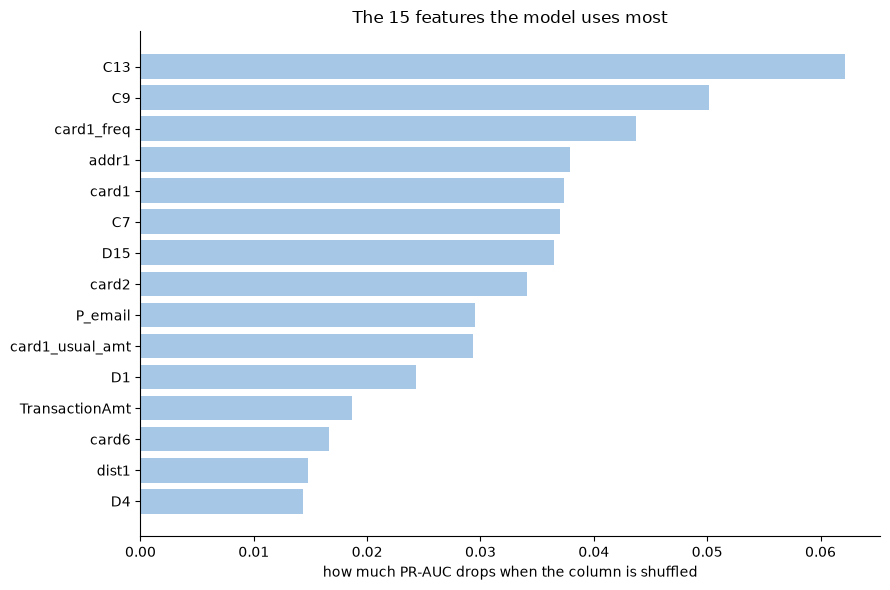

In [8]:
sample = valid.sample(20000, random_state=0) if len(valid) > 20000 else valid
importance = permutation_importance(model, sample[FEATURES], sample["isFraud"],
                                    scoring="average_precision", n_repeats=3, random_state=0)
top = (pd.Series(importance.importances_mean, index=FEATURES)
         .sort_values(ascending=False).head(15))

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top.index[::-1], top.values[::-1], color=BLUE)
ax.set_xlabel("how much PR-AUC drops when the column is shuffled")
ax.set_title("The 15 features the model uses most")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(IMAGES / "feature_importance.png", dpi=120)
plt.show()

## 8. Save

- the model → `models/fraud_model.joblib`
- the threshold and the settings → `models/model_info.json`
- the test month with scores → `data/processed/test_scores.parquet` (for the app and the agent)

In [9]:
Path("../models").mkdir(exist_ok=True)
joblib.dump(model, "../models/fraud_model.joblib")
json.dump({"threshold": THRESHOLD, "flag_share": FLAG_SHARE, "params": best_params,
           "features": FEATURES, "categories": CATEGORIES},
          open("../models/model_info.json", "w"), indent=1)
test.to_parquet("../data/processed/test_scores.parquet", index=False)
print("saved: model, threshold, test scores")

saved: model, threshold, test scores
